In [1]:
import random

class SafeGridWorldEnv:
    
    def __init__(self, random_start=False, step_penalty=-0.1):
        # grid size
        self.rows = 10
        self.cols = 10
        
        # position
        self.start_pos = (0, 0)
        self.goal_pos = (9, 9)
        
        # hazard
        self.hazard_pos = set([
            (0, 3), (1, 1), (1, 7), (2, 4), (2, 8), (3, 2), (3, 6), (4, 5),
            (5, 3), (5, 8), (6, 1), (6, 6), (7, 4), (8, 2), (8, 7)
        ])
        
        # goal
        self.goal_reward = 10.0
        self.hazard_penalty = -10.0
        self.step_penalty = step_penalty
        
        # movement
        self.action_map = {
            0: (-1, 0),  # up
            1: (1, 0),   # down
            2: (0, -1),  # left
            3: (0, 1)    # right
        }
        
        # set the spacesize
        self.action_space_size = len(self.action_map)
        
        # rand mode
        self.random_start = random_start
        self.safe_cells = [] # find the safe start
        for r in range(self.rows):
            for c in range(self.cols):
                pos = (r, c)
                if pos != self.goal_pos and pos not in self.hazard_pos:
                    self.safe_cells.append(pos)
        
        # current position
        self.current_pos = None
        
    def reset(self):
        if self.random_start:
            self.current_pos = random.choice(self.safe_cells)
        else:
            self.current_pos = self.start_pos
            
        return self.current_pos

    def step(self, action):
        (r, c) = self.current_pos
        (dr, dc) = self.action_map[action]
        new_r, new_c = r + dr, c + dc
        
        if new_r < 0 or new_r >= self.rows or new_c < 0 or new_c >= self.cols:
            next_pos = self.current_pos
        else:
            next_pos = (new_r, new_c)
            
        self.current_pos = next_pos
        
        done = False
        is_hazard = False
        
        if self.current_pos == self.goal_pos:
            reward = self.goal_reward
            done = True
        elif self.current_pos in self.hazard_pos:
            reward = self.hazard_penalty
            done = True
            is_hazard = True
        else:
            reward = self.step_penalty
        
        # to tell the
        info = {'hazard': is_hazard}
            
        return self.current_pos, reward, done, info

    def render(self):
        for r in range(self.rows):
            line = ""
            for c in range(self.cols):
                pos = (r, c)
                if pos == self.current_pos:
                    cell = " A "
                elif pos == self.goal_pos:
                    cell = " G "
                elif pos in self.hazard_pos:
                    cell = " X "
                elif pos == self.start_pos:
                    cell = " S "
                else:
                    cell = " . "
                line += cell
            print(line)
        print("-" * (self.cols * 3)) 

--- Step Penalty = -1.0 ---
train_start: 2000 round。
  round200/2000 finish. Epsilon: 0.367
  round400/2000 finish. Epsilon: 0.135
  round600/2000 finish. Epsilon: 0.049
  round800/2000 finish. Epsilon: 0.018
  round1000/2000 finish. Epsilon: 0.010
  round1200/2000 finish. Epsilon: 0.010
  round1400/2000 finish. Epsilon: 0.010
  round1600/2000 finish. Epsilon: 0.010
  round1800/2000 finish. Epsilon: 0.010
  round2000/2000 finish. Epsilon: 0.010
tarin finish. Time: 1.19.
Penalty = -1.0 done

--- Step Penalty = -0.1 ---
train_start: 2000 round。
  round200/2000 finish. Epsilon: 0.367
  round400/2000 finish. Epsilon: 0.135
  round600/2000 finish. Epsilon: 0.049
  round800/2000 finish. Epsilon: 0.018
  round1000/2000 finish. Epsilon: 0.010
  round1200/2000 finish. Epsilon: 0.010
  round1400/2000 finish. Epsilon: 0.010
  round1600/2000 finish. Epsilon: 0.010
  round1800/2000 finish. Epsilon: 0.010
  round2000/2000 finish. Epsilon: 0.010
tarin finish. Time: 1.17.
Step Penalty = -0.1 done


  

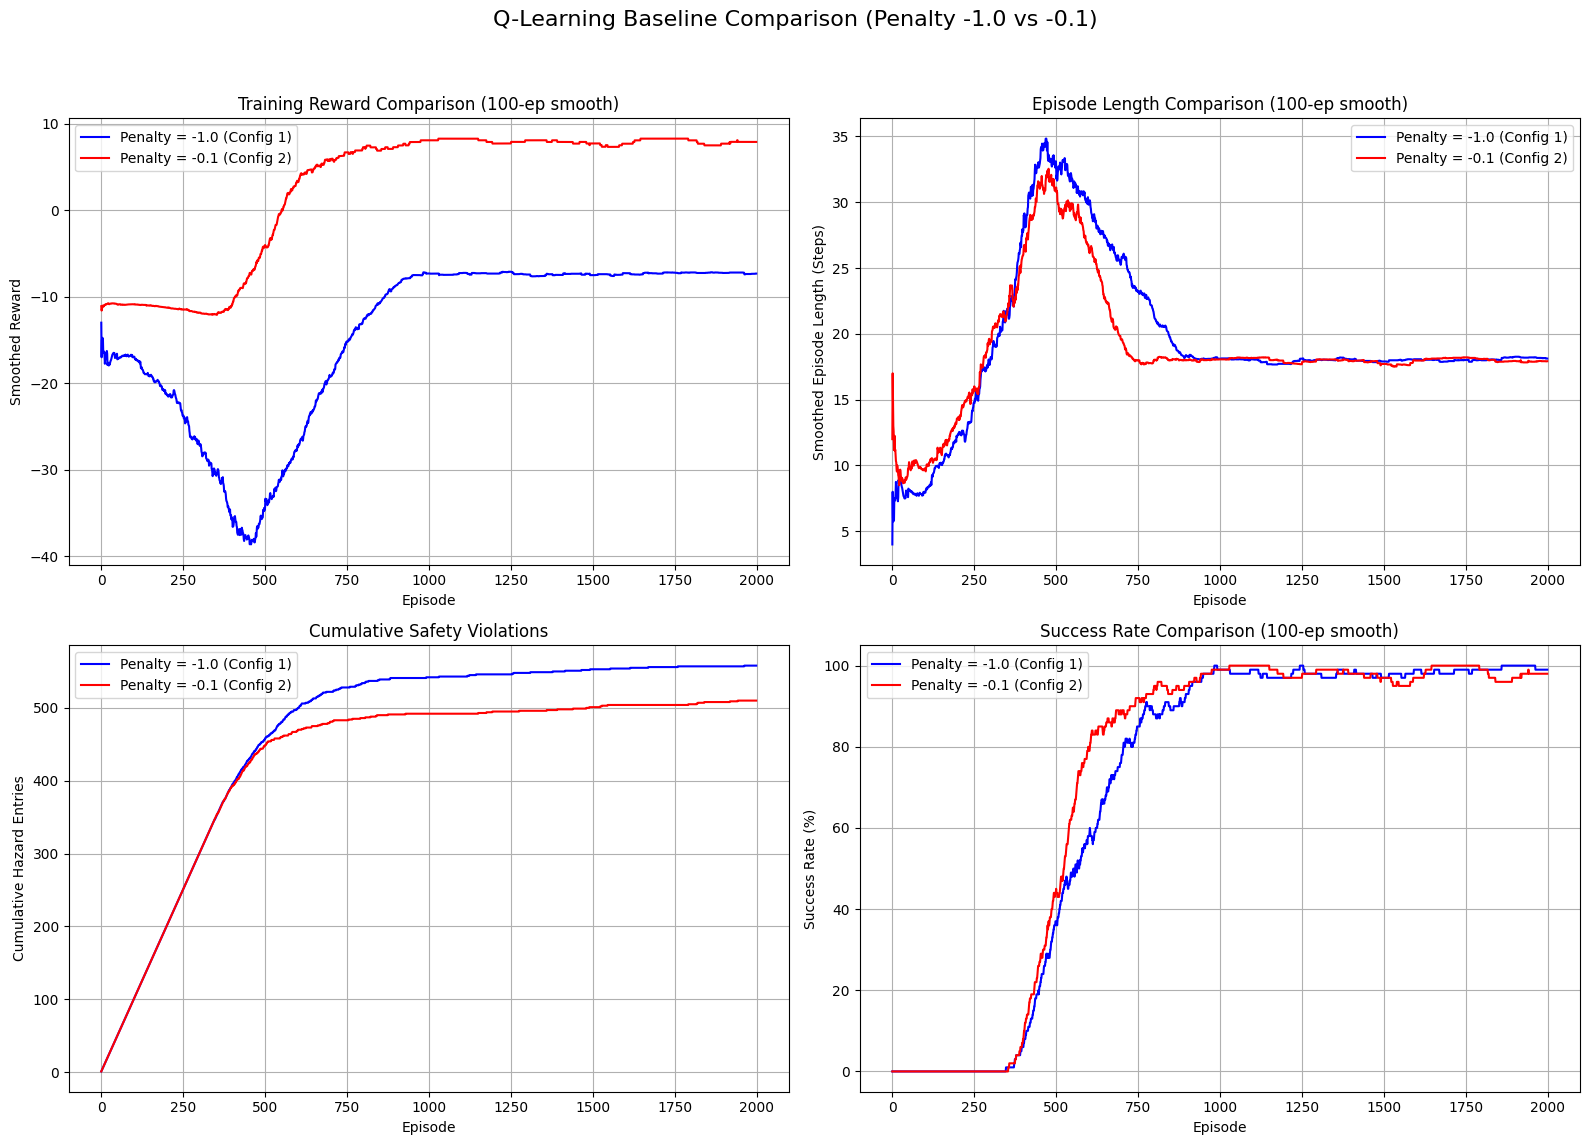

baseline_q_agent_config1.pkl saved


In [2]:
import numpy as np
import time
import pickle
import pandas as pd
import matplotlib.pyplot as plt

def train_q_learning(env, hyperparams):
    # init
    alpha = hyperparams['alpha']
    gamma = hyperparams['gamma']
    epsilon_start = hyperparams['epsilon_start']
    epsilon_min = hyperparams['epsilon_min']
    epsilon_decay = hyperparams['epsilon_decay']
    n_episodes = hyperparams['n_episodes']
    max_steps = hyperparams['max_steps']

    # init Q-table
    q_table = np.zeros((env.rows, env.cols, env.action_space_size))
    
    all_rewards = []
    all_lengths = []
    all_violations = []
    all_success = []
    
    epsilon = epsilon_start
    start_time = time.time()

    print(f"train_start: {n_episodes} round。")

    # training(2000 times)
    for episode in range(n_episodes):
        episode_reward = 0
        episode_length = 0
        episode_violations = 0
        
        state = env.reset()
        (r, c) = state
        
        for step in range(max_steps):
            # choose an movement(greedy)
            if random.uniform(0, 1) < epsilon:
                action = random.randint(0, env.action_space_size - 1)
            else:
                action = np.argmax(q_table[r, c, :])
            
            next_state, reward, done, info = env.step(action)
            (next_r, next_c) = next_state
            
            # update Q-table
            old_q_value = q_table[r, c, action]
            max_future_q = np.max(q_table[next_r, next_c, :]) if not done else 0.0
            target_q_value = reward + gamma * max_future_q
            td_error = target_q_value - old_q_value
            
            q_table[r, c, action] = old_q_value + alpha * td_error
            
            episode_reward += reward
            episode_length += 1
            if info['hazard']:
                episode_violations += 1
                
            state = next_state
            (r, c) = state
            
            if done:
                break
        
        # round finish
        all_success.append(1 if state == env.goal_pos else 0)
        all_rewards.append(episode_reward)
        all_lengths.append(episode_length)
        all_violations.append(episode_violations)
        
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        
        if (episode + 1) % 200 == 0:
            print(f"  round{episode + 1}/{n_episodes} finish. Epsilon: {epsilon:.3f}")

    end_time = time.time()
    total_time = end_time - start_time
    print(f"tarin finish. Time: {total_time:.2f}.")
    
    metrics = {
        'rewards': all_rewards,
        'lengths': all_lengths,
        'violations': all_violations,
        'success': all_success,
        'total_time': total_time
    }
    
    return q_table, metrics

def calculate_summary_metrics(metrics, n_episodes):
    # sum the data for last 500 round
    M = int(0.25 * n_episodes)
    last_m_rewards = metrics['rewards'][-M:]
    last_m_lengths = metrics['lengths'][-M:]
    last_m_success = metrics['success'][-M:]
    
    success_rate = np.mean(last_m_success) * 100
    average_reward = np.mean(last_m_rewards)
    episode_length = np.mean(last_m_lengths)
    
    total_violations = np.sum(metrics['violations'])
    training_speed = n_episodes / metrics['total_time']
    
    return {
        "Success Rate": success_rate,
        "Average Reward": average_reward,
        "Episode Length": episode_length,
        "Total Violations": total_violations,
        "Training Speed (eps/sec)": training_speed
    }

def plot_comparison(metrics1, metrics2, n_episodes):
    # draw the graph
    window_size = 100 # rolling window
    
    df = pd.DataFrame({
        'reward_1': metrics1['rewards'],
        'reward_2': metrics2['rewards'],
        'length_1': metrics1['lengths'],
        'length_2': metrics2['lengths'],
        'success_1': metrics1['success'],
        'success_2': metrics2['success'],
    })
    
    smooth_df = df.rolling(window=window_size, min_periods=1).mean()
    
    cum_violations_1 = np.cumsum(metrics1['violations'])
    cum_violations_2 = np.cumsum(metrics2['violations'])
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Q-Learning Baseline Comparison (Penalty -1.0 vs -0.1)', fontsize=16)
    
    # reward graph
    axes[0, 0].plot(smooth_df['reward_1'], label='Penalty = -1.0 (Config 1)', color='blue')
    axes[0, 0].plot(smooth_df['reward_2'], label='Penalty = -0.1 (Config 2)', color='red')
    axes[0, 0].set_title('Training Reward Comparison (100-ep smooth)')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Smoothed Reward')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # length graph
    axes[0, 1].plot(smooth_df['length_1'], label='Penalty = -1.0 (Config 1)', color='blue')
    axes[0, 1].plot(smooth_df['length_2'], label='Penalty = -0.1 (Config 2)', color='red')
    axes[0, 1].set_title('Episode Length Comparison (100-ep smooth)')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Smoothed Episode Length (Steps)')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # hazard graph
    axes[1, 0].plot(cum_violations_1, label='Penalty = -1.0 (Config 1)', color='blue')
    axes[1, 0].plot(cum_violations_2, label='Penalty = -0.1 (Config 2)', color='red')
    axes[1, 0].set_title('Cumulative Safety Violations')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('Cumulative Hazard Entries')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # success rate graph
    axes[1, 1].plot(smooth_df['success_1'] * 100, label='Penalty = -1.0 (Config 1)', color='blue')
    axes[1, 1].plot(smooth_df['success_2'] * 100, label='Penalty = -0.1 (Config 2)', color='red')
    axes[1, 1].set_title('Success Rate Comparison (100-ep smooth)')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Success Rate (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# init the table 1
BASELINE_HYPERPARAMS = {
    'alpha': 0.1,                # learning rate
    'gamma': 0.99,              
    'epsilon_start': 1.0,       
    'epsilon_min': 0.01,         
    'epsilon_decay': 0.995,      
    'n_episodes': 2000,          # training steps
    'max_steps': 200          
}

print("--- Step Penalty = -1.0 ---")
env_config1 = SafeGridWorldEnv(random_start=False, step_penalty=-1.0)
q_table_1, metrics_1 = train_q_learning(env_config1, BASELINE_HYPERPARAMS)
summary_1 = calculate_summary_metrics(metrics_1, BASELINE_HYPERPARAMS['n_episodes'])
print("Penalty = -1.0 done")

print("\n--- Step Penalty = -0.1 ---")
env_config2 = SafeGridWorldEnv(random_start=False, step_penalty=-0.1)
q_table_2, metrics_2 = train_q_learning(env_config2, BASELINE_HYPERPARAMS)
summary_2 = calculate_summary_metrics(metrics_2, BASELINE_HYPERPARAMS['n_episodes'])
print("Step Penalty = -0.1 done")

print("\n\n" + "=" * 80)
print("                           Q-Learning Baseline compare")
print("="*80 )

comparison_data = {
    "Metric": list(summary_1.keys()),
    "Config 1 (Penalty=-1.0)": list(summary_1.values()),
    "Config 2 (Penalty=-0.1)": list(summary_2.values())
}
df = pd.DataFrame(comparison_data)
print(df.to_string(index=False, float_format="%.2f"))
print("="*80 + "\n\n")


# show the graph
plot_comparison(metrics_1, metrics_2, BASELINE_HYPERPARAMS['n_episodes'])

# save table (the better one)
if summary_2['Success Rate'] > summary_1['Success Rate']:
    best_q_table = q_table_2
    best_summary = summary_2
    filename = 'baseline_q_agent_config2.pkl'
else:
    best_q_table = q_table_1
    best_summary = summary_1
    filename = 'baseline_q_agent_config1.pkl'
    
data_to_save = {
    'q_table': best_q_table,
    'summary_metrics': best_summary,
    'hyperparams': BASELINE_HYPERPARAMS
}

with open(filename, 'wb') as f:
    pickle.dump(data_to_save, f)

print(f"{filename} saved")

In [3]:
import numpy as np
import pickle
from collections import deque
from sklearn.model_selection import train_test_split
import time


# step 1 (BFS)
def compute_danger_map(env):

    # init the map
    danger_map = np.full((env.rows, env.cols), np.inf)
    
    # init queue
    queue = deque()
    
    # set hazard as the start
    for h_pos in env.hazard_pos:
        danger_map[h_pos] = 0
        queue.append(h_pos)
        
    # BFS
    while queue:
        (r, c) = queue.popleft()
        current_dist = danger_map[r, c]
        
        # check all the 4 neighbors
        for (dr, dc) in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            
            # if neighbor is in the grid
            if 0 <= nr < env.rows and 0 <= nc < env.cols:
                if danger_map[nr, nc] == np.inf:
                    danger_map[nr, nc] = current_dist + 1
                    queue.append((nr, nc))
                    
    return danger_map

# Step 2 (algor 2)

def compute_next_position(s, a, env):
    (r, c) = s
    (dr, dc) = env.action_map[a]
    new_r, new_c = r + dr, c + dc
    
    # if hit the wall
    if new_r < 0 or new_r >= env.rows or new_c < 0 or new_c >= env.cols:
        return s
    else:
        return (new_r, new_c)

def generate_labelled_dataset(env, danger_map):
    
    raw_dataset = []
    
    # for all situation
    for r in range(env.rows):
        for c in range(env.cols):
            s = (r, c)
            
            # algorithm 2: skip hazard and goal
            if s in env.hazard_pos or s == env.goal_pos:
                continue
                
            # for 4 nieghbors
            for a in env.action_map.keys():
                
                # next move
                s_prime = compute_next_position(s, a, env)
                
                # danger
                d = danger_map[s_prime]
                
                # risk level
                if d == 0:
                    c = 0  # into hazard
                elif d == 1:
                    c = 1  # next to hazard
                elif d == 2:
                    c = 2  # 2 step ...
                else:
                    c = 3  # safe
                    
                raw_dataset.append((s, a, s_prime, c))
                
    return raw_dataset

# step 3
def extract_features_and_split(raw_dataset, danger_map, env):
    # feature extraction
    features_X = []
    labels_y = []
    
    # normalization
    grid_size = env.rows # 10
    danger_norm = 10.0
    
    # for all the raw data
    for (s, a, s_prime, c) in raw_dataset:
        
        # add lable
        labels_y.append(c)
        
        # build 10d-feature
        
        # feature[1-2]: s location(x,y)
        s_norm = [s[0] / grid_size, s[1] / grid_size]
        
        # feature[3-6]: a (one-hot movement dirc)
        a_one_hot = np.zeros(env.action_space_size)
        a_one_hot[a] = 1.0
        
        # feature[7-8]: s' location(x',y')
        s_prime_norm = [s_prime[0] / grid_size, s_prime[1] / grid_size]
        
        # feature[9]: D(s)
        danger_s = danger_map[s] / danger_norm
        
        # feature[10]: D(s')
        danger_s_prime = danger_map[s_prime] / danger_norm
        
        # combine
        x_vec = s_norm + list(a_one_hot) + s_prime_norm + [danger_s] + [danger_s_prime]
        features_X.append(x_vec)

    X = np.array(features_X)
    y = np.array(labels_y)
    
    # split the dataset
    
    # 70% training / 30% temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, 
        test_size=0.30, 
        random_state=42, 
        stratify=y
    )
    
    # 30% temp to 15% val / 15% test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, 
        test_size=0.50, # (0.50 * 0.30 = 0.15)
        random_state=42, 
        stratify=y_temp
    )
    
    return X_train, y_train, X_val, y_val, X_test, y_test


# main
if __name__ == "__main__":
    start_time = time.time()
    
    env = SafeGridWorldEnv()
    # cal the map
    danger_map = compute_danger_map(env)      
    # print(danger_map)

    # lable
    raw_dataset = generate_labelled_dataset(env, danger_map)

    # split
    (X_train, y_train, X_val, y_val, X_test, y_test) = extract_features_and_split(raw_dataset, danger_map, env)       
    print(f"    Train: {len(X_train)}")
    print(f"    Val:   {len(X_val)}")
    print(f"    Test:   {len(X_test)}")

    # save the dataset
    output_filename = 'complete_dataset.pkl'
    dataset_to_save = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val,     'y_val': y_val,
        'X_test': X_test,   'y_test': y_test,
    }       
    with open(output_filename, 'wb') as f:
        pickle.dump(dataset_to_save, f)

    Train: 235
    Val:   50
    Test:   51


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)               │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_2 (Dense)               │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,124 (20.02 KB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.2383 - loss: 1.3946 - val_accuracy: 0.4600 - val_loss: 1.3389
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4894 - loss: 1.3259 - val_accuracy: 0.4800 - val_loss: 1.2896
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4809 - loss: 1.2793 - val_accuracy: 0.4800 - val_loss: 1.2554
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4809 - loss: 1.2438 - val_accuracy: 0.4800 - val_loss: 1.2349
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4809 - loss: 1.2197 - val_accuracy: 0.4800 - val_loss: 1.2250
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4809 - loss: 1.2040 - val_accuracy: 0.4800 - val_loss: 1.2188
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4809 - loss: 1.1930 - val_accuracy: 0.4800 - val_loss: 1.2128
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4809 - loss: 1.1843 - val_accuracy: 0.4800 - val_loss:

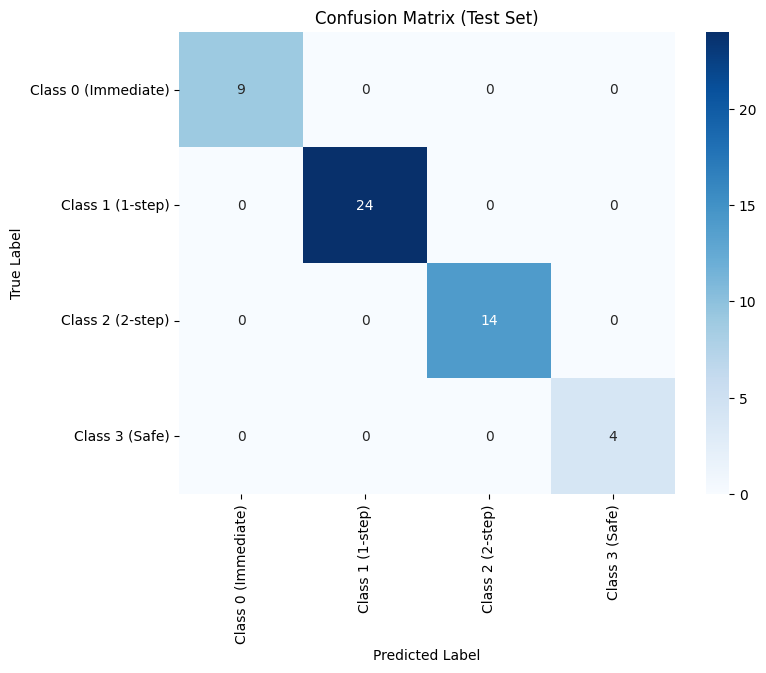

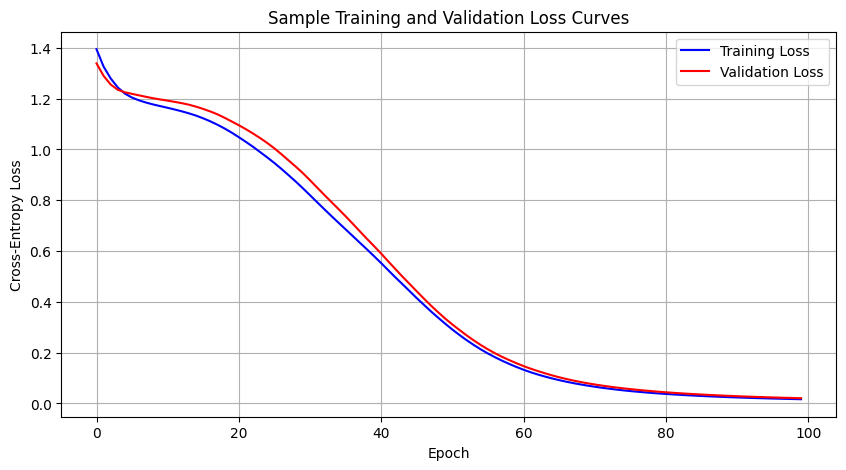

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import random
import os

# set the seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# load dataset
try:
    with open('complete_dataset.pkl', 'rb') as f:
        dataset = pickle.load(f)
    
    X_train = dataset['X_train']
    y_train = dataset['y_train']
    X_val = dataset['X_val']
    y_val = dataset['y_val']
    X_test = dataset['X_test']
    y_test = dataset['y_test']    

except FileNotFoundError:
    print("\n no such file")
    raise

# init the network
# use the baseline
INPUT_SHAPE = (10,)
model = keras.Sequential([
    layers.Input(shape=INPUT_SHAPE, name='Input_Layer'),
    layers.Dense(64, activation='relu', name='Hidden_Layer_1'),
    layers.Dense(64, activation='relu', name='Hidden_Layer_2'),
    layers.Dense(4, activation='softmax', name='Output_Layer')
])
model.summary()

# optimizer
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# training
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val), 
    verbose=1
)

print("Done")

# output
# test on val
loss, overall_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n---Test Set ---")
print(f"\nOverall Accuracy: {overall_acc * 100:.2f}%")

# report
class_names = ['Class 0 (Immediate)', 'Class 1 (1-step)', 
               'Class 2 (2-step)', 'Class 3 (Safe)']
report_str = classification_report(y_test, y_pred_classes, target_names=class_names)
report_dict = classification_report(y_test, y_pred_classes, output_dict=True)
print(report_str)

# check the recall
class_0_recall = report_dict['0']['recall']
if class_0_recall > 0.95:
    print(f"  Recall: {class_0_recall * 100:.2f}% ( > 95%)")
else:
    print(f"  Recall: {class_0_recall * 100:.2f}% ( < 95% )")
print("="*40)


# matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# graph
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Sample Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()


# save model
MODEL_FILENAME = 'safety_shield_model.h5'
model.save(MODEL_FILENAME)


  Baseline (No Shield): round 200/1000 finish
  Baseline (No Shield): round 400/1000 finish
  Baseline (No Shield): round 600/1000 finish
  Baseline (No Shield): round 800/1000 finish
  Baseline (No Shield): round 1000/1000 finish
  Safe RL (theta=0): round 200/1000 finish
  Safe RL (theta=0): round 400/1000 finish
  Safe RL (theta=0): round 600/1000 finish
  Safe RL (theta=0): round 800/1000 finish
  Safe RL (theta=0): round 1000/1000 finish
  Safe RL (theta=2): round 200/1000 finish
  Safe RL (theta=2): round 400/1000 finish
  Safe RL (theta=2): round 600/1000 finish
  Safe RL (theta=2): round 800/1000 finish
  Safe RL (theta=2): round 1000/1000 finish


          Safe RL vs Baseline
                      Metric  Baseline (No Shield)  Safe RL (θ=0)  Safe RL (θ=2)
       Avg Reward (Last 100)                  8.92           9.07         -19.40
     Success Rate (Last 100)                 99.00         100.00           2.00
       Avg Length (Last 100)                  9.80          10

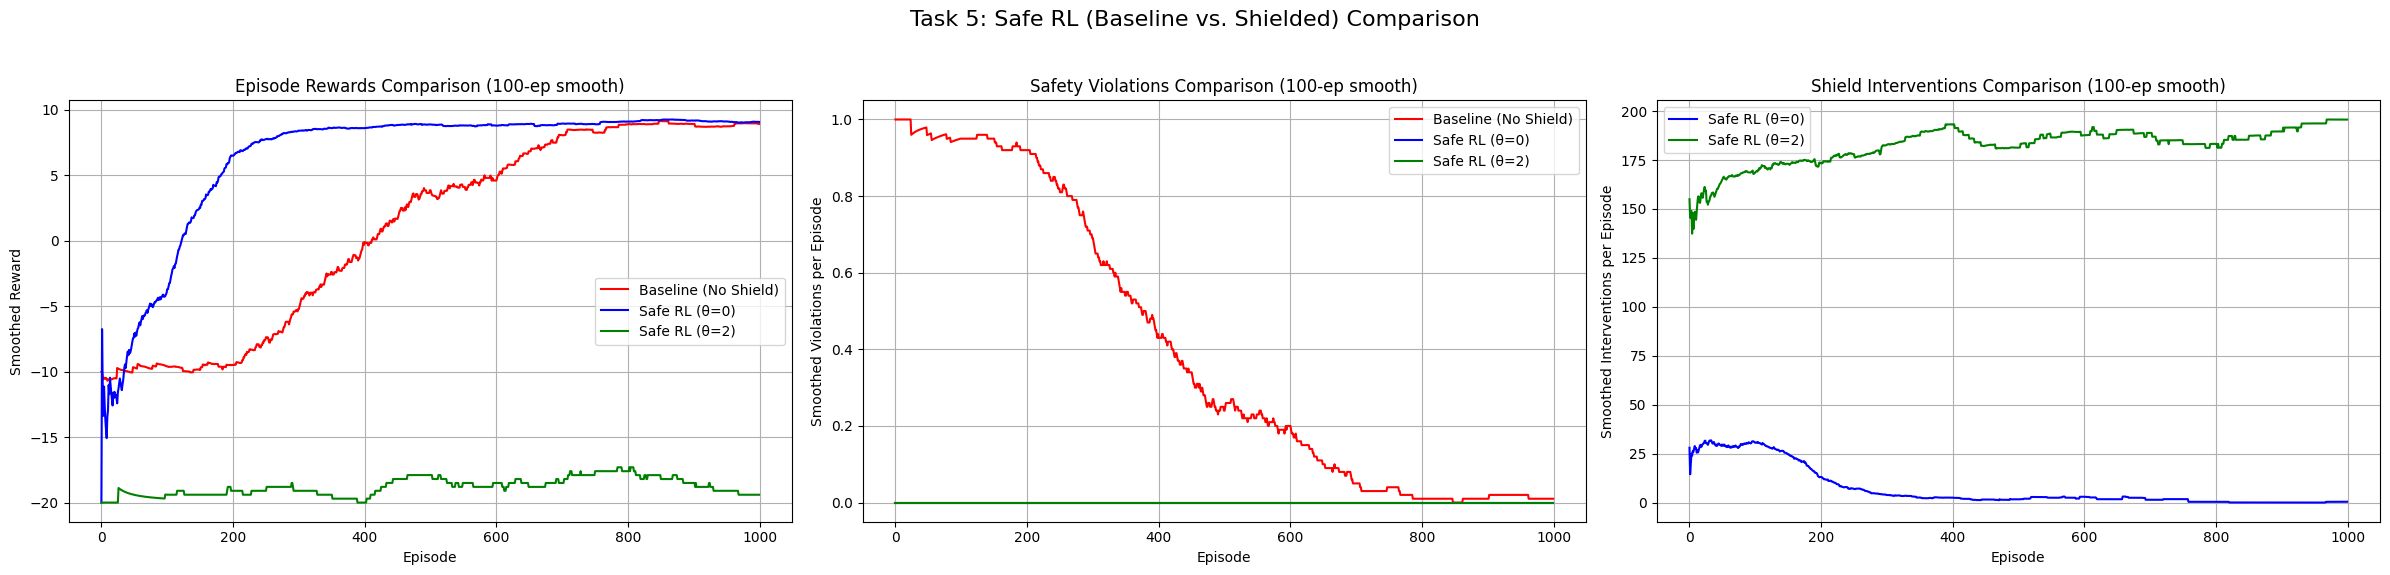

In [5]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import random
import time
import os
from collections import deque

# set seed

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# from task 3
def compute_danger_map(env):
    danger_map = np.full((env.rows, env.cols), np.inf)
    queue = deque()
    for h_pos in env.hazard_pos:
        danger_map[h_pos] = 0
        queue.append(h_pos)
    
    while queue:
        (r, c) = queue.popleft()
        current_dist = danger_map[r, c]
        for (dr, dc) in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < env.rows and 0 <= nc < env.cols:
                if danger_map[nr, nc] == np.inf:
                    danger_map[nr, nc] = current_dist + 1
                    queue.append((nr, nc))
    return danger_map

# from task 3
def compute_next_position(s, a, env):
    (r, c) = s
    (dr, dc) = env.action_map[a]
    new_r, new_c = r + dr, c + dc
    if new_r < 0 or new_r >= env.rows or new_c < 0 or new_c >= env.cols:
        return s
    else:
        return (new_r, new_c)

# from task 3
def build_feature_vector(s, a, s_prime, danger_map, env):
    grid_size = env.rows
    danger_norm = 10.0
    
    s_norm = [s[0] / grid_size, s[1] / grid_size]
    
    a_one_hot = np.zeros(env.action_space_size)
    a_one_hot[a] = 1.0
    
    s_prime_norm = [s_prime[0] / grid_size, s_prime[1] / grid_size]
    
    danger_s = danger_map[s] / danger_norm
    danger_s_prime = danger_map[s_prime] / danger_norm
    
    x_vec = s_norm + list(a_one_hot) + s_prime_norm + [danger_s] + [danger_s_prime]
    return x_vec

# precal the risk for each block
def precompute_shield_predictions(shield_model, env, danger_map):
    # save the 84 * 4 = 336 movement risk into a dict
    shield_cache = {}
    
    for r in range(env.rows):
        for c in range(env.cols):
            s = (r, c)
            # skip hazard and goal
            if s == env.goal_pos or s in env.hazard_pos:
                continue
                
            batch_X = []
            for a in range(env.action_space_size):
                s_prime = compute_next_position(s, a, env)
                x_vec = build_feature_vector(s, a, s_prime, danger_map, env)
                batch_X.append(x_vec)
            
            pred_probs = shield_model.predict(np.array(batch_X), verbose=0)
            pred_classes = np.argmax(pred_probs, axis=1)
            
            shield_cache[s] = pred_classes
            
    return shield_cache

# train with shield
def train_safe_rl(env, hyperparams, shield_cache, mode='baseline', theta=0):

    # init
    alpha = hyperparams['alpha']
    gamma = hyperparams['gamma']
    epsilon_start = hyperparams['epsilon_start']
    epsilon_min = hyperparams['epsilon_min']
    epsilon_decay = hyperparams['epsilon_decay']
    n_episodes = hyperparams['n_episodes']
    max_steps = hyperparams['max_steps']
    
    # init Q-Table
    q_table = np.zeros((env.rows, env.cols, env.action_space_size))
    
    all_rewards = []
    all_lengths = []
    all_violations = []
    all_success = []
    all_interventions = []
    
    epsilon = epsilon_start
    start_time = time.time()
    
    mode_str = f"Safe RL (theta={theta})" if mode == 'safe_rl' else "Baseline (No Shield)"

    # train for n rounds
    for episode in range(n_episodes):
        episode_reward = 0
        episode_length = 0
        episode_violations = 0
        episode_interventions = 0
        
        # random start
        state = env.reset() 
        (r, c) = state
        
        for step in range(max_steps):        
            # same as task 2 (greedy)
            if random.uniform(0, 1) < epsilon:
                a_prop = random.randint(0, env.action_space_size - 1)  # exploration
            else:
                a_prop = np.argmax(q_table[r, c, :])  # exploitation
            
            intervention_occured = False
            a_exec = a_prop # move
            
            # shield
            if mode == 'safe_rl':
                # check from dict
                risks = shield_cache[state]
                
                if risks[a_prop] <= theta: # in danger, find movement in action list
                    intervention_occured = True
                    episode_interventions += 1
                    acceptable_actions = [a for a in range(env.action_space_size) if risks[a] > theta]
                    
                    if len(acceptable_actions) > 0:
                        # choose the highest Q
                        best_q = -np.inf
                        best_a = acceptable_actions[0]
                        for a_acc in acceptable_actions:
                            if q_table[r, c, a_acc] > best_q:
                                best_q = q_table[r, c, a_acc]
                                best_a = a_acc
                        a_exec = best_a
                    
                    else:
                        # choose the lowest risk
                        c_max = np.max(risks)
                        least_risky_actions = [a for a in range(env.action_space_size) if risks[a] == c_max]
                        best_q = -np.inf
                        best_a = least_risky_actions[0]
                        for a_lrisk in least_risky_actions:
                            if q_table[r, c, a_lrisk] > best_q:
                                best_q = q_table[r, c, a_lrisk]
                                best_a = a_lrisk
                        a_exec = best_a
            
            # move
            next_state, reward, done, info = env.step(a_exec)
            (next_r, next_c) = next_state
            
            # update Q-table
            old_q_value = q_table[r, c, a_exec]
            max_future_q = np.max(q_table[next_r, next_c, :]) if not done else 0.0
            target_q_value = reward + gamma * max_future_q
            new_q_value = old_q_value + alpha * (target_q_value - old_q_value)
            q_table[r, c, a_exec] = new_q_value
            
            # update info
            episode_reward += reward
            episode_length += 1
            if info['hazard']:
                episode_violations += 1
            
            state = next_state
            (r, c) = state
            
            if done:
                break
        
        # finish
        all_success.append(1 if state == env.goal_pos else 0)
        all_rewards.append(episode_reward)
        all_lengths.append(episode_length)
        all_violations.append(episode_violations)
        all_interventions.append(episode_interventions)
        
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        
        if (episode + 1) % 200 == 0:
            print(f"  {mode_str}: round {episode + 1}/{n_episodes} finish")

    end_time = time.time()
    total_time = end_time - start_time

    metrics = {
        'rewards': all_rewards, 'lengths': all_lengths,
        'violations': all_violations, 'success': all_success,
        'interventions': all_interventions, 'total_time': total_time
    }
    return q_table, metrics

# report

def calculate_summary_metrics_t5(metrics, n_episodes):
    M = 100
    last_m_rewards = metrics['rewards'][-M:]
    last_m_lengths = metrics['lengths'][-M:]
    last_m_success = metrics['success'][-M:]
    last_m_interventions = metrics['interventions'][-M:]
    total_violations = np.sum(metrics['violations'])
    
    return {
        "Avg Reward (Last 100)": np.mean(last_m_rewards),
        "Success Rate (Last 100)": np.mean(last_m_success) * 100,
        "Avg Length (Last 100)": np.mean(last_m_lengths),
        "Total Violations (All 1k)": total_violations,
        "Total Interventions (All 1k)": np.sum(metrics['interventions']),
        "Avg Interventions (Last 100)": np.mean(last_m_interventions),
    }

def plot_comparison_t5(metrics_base, metrics_t0, metrics_t2, n_episodes):
    # graph
    window_size = 100
    
    df = pd.DataFrame({
        'reward_base': metrics_base['rewards'],
        'reward_t0': metrics_t0['rewards'],
        'reward_t2': metrics_t2['rewards'],
        
        'violations_base': metrics_base['violations'],
        'violations_t0': metrics_t0['violations'],
        'violations_t2': metrics_t2['violations'],

        'interv_t0': metrics_t0['interventions'],
        'interv_t2': metrics_t2['interventions'],
    })
    
    smooth_df = df.rolling(window=window_size, min_periods=1).mean()
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    fig.suptitle('Task 5: Safe RL (Baseline vs. Shielded) Comparison', fontsize=16)
    
    # reward
    axes[0].plot(smooth_df['reward_base'], label='Baseline (No Shield)', color='red')
    axes[0].plot(smooth_df['reward_t0'], label='Safe RL (θ=0)', color='blue')
    axes[0].plot(smooth_df['reward_t2'], label='Safe RL (θ=2)', color='green')
    axes[0].set_title('Episode Rewards Comparison (100-ep smooth)')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Smoothed Reward')
    axes[0].legend()
    axes[0].grid(True)
    
    # safe
    axes[1].plot(smooth_df['violations_base'], label='Baseline (No Shield)', color='red')
    axes[1].plot(smooth_df['violations_t0'], label='Safe RL (θ=0)', color='blue')
    axes[1].plot(smooth_df['violations_t2'], label='Safe RL (θ=2)', color='green')
    axes[1].set_title('Safety Violations Comparison (100-ep smooth)')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Smoothed Violations per Episode')
    axes[1].legend()
    axes[1].grid(True)
    
    # shield
    axes[2].plot(smooth_df['interv_t0'], label='Safe RL (θ=0)', color='blue')
    axes[2].plot(smooth_df['interv_t2'], label='Safe RL (θ=2)', color='green')
    axes[2].set_title('Shield Interventions Comparison (100-ep smooth)')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Smoothed Interventions per Episode')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# main
if __name__ == "__main__":
    
    # init
    env_t5 = SafeGridWorldEnv(random_start=True)
        
    # load shield
    shield_model = keras.models.load_model('safety_shield_model.h5')
        
    # cal map
    danger_map = compute_danger_map(env_t5)
    shield_cache = precompute_shield_predictions(shield_model, env_t5, danger_map)
        
    # init
    H_PARAMS_T5 = {
        'alpha': 0.1,
        'gamma': 0.99,
        'epsilon_start': 1.0,
        'epsilon_min': 0.01,
        'epsilon_decay': 0.995,
        'n_episodes': 1000, 
        'max_steps': 200
    }
        
    # no shield
    _, metrics_baseline = train_safe_rl(
        env_t5, H_PARAMS_T5, shield_cache, mode='baseline'
    )
        
    # shield (Theta=0)
    _, metrics_theta0 = train_safe_rl(
        env_t5, H_PARAMS_T5, shield_cache, mode='safe_rl', theta=0
    )
        
    #  shield (Theta=2)
    _, metrics_theta2 = train_safe_rl(
        env_t5, H_PARAMS_T5, shield_cache, mode='safe_rl', theta=2
    )
        
    # report
    print("\n\n" + "="*70)
    print("          Safe RL vs Baseline")
    print("="*70)
        
    summary_base = calculate_summary_metrics_t5(metrics_baseline, H_PARAMS_T5['n_episodes'])
    summary_t0 = calculate_summary_metrics_t5(metrics_theta0, H_PARAMS_T5['n_episodes'])
    summary_t2 = calculate_summary_metrics_t5(metrics_theta2, H_PARAMS_T5['n_episodes'])
        
    summary_data = {
        "Metric": list(summary_base.keys()),
        "Baseline (No Shield)": list(summary_base.values()),
        "Safe RL (θ=0)": list(summary_t0.values()),
        "Safe RL (θ=2)": list(summary_t2.values())
    }
    df_summary = pd.DataFrame(summary_data)
    print(df_summary.to_string(index=False, float_format="%.2f"))
    print("="*70)

    plot_comparison_t5(metrics_baseline, metrics_theta0, metrics_theta2, H_PARAMS_T5['n_episodes'])